In [32]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import json
import os

sns.set_style("darkgrid")

In [48]:
TASKS_METRICS = {
    'coherence': ['accuracy', 'f1'],
    'complexity': ['mae', 'spearmanr'],
    'sentiment':['neg_accuracy', 'neg_f1', 'pos_accuracy', 'pos_f1']
}

In [10]:
def load_trainer_state(src_path):
    with open(src_path, 'r') as src_file:
        trainer_state = json.load(src_file)
    return trainer_state

In [17]:
def get_last_epoch_eval_metrics(trainer_state, metrics):
    res = {metric: None for metric in metrics}
    last_epoch = 0 
    for el in trainer_state['log_history']:
        if 'eval_loss' in el:
            for metric in metrics:
                res[metric] = el[f'eval_{metric}']
            last_epoch = int(el['epoch'])
    assert last_epoch == 10
    return res


In [24]:
def add_to_result_dict(res_dict, checkpoint, eval_metrics):
    for metric in eval_metrics:
        res_dict['checkpoint'].append(checkpoint)
        res_dict['metric'].append(metric)
        res_dict['score'].append(eval_metrics[metric])

In [37]:
def get_model_results(models_dir, model_name):
    res_dict = {'checkpoint':[], 'metric':[], 'score':[]}
    model_dir = os.path.join(models_dir, model_name)
    for checkpoint_name in os.listdir(model_dir):
        checkpoint_num = int(checkpoint_name.split('-')[-1])
        trainer_state_path = os.path.join(model_dir, checkpoint_name, 'trainer_state.json')
        trainer_state = load_trainer_state(trainer_state_path)
        eval_metrics = get_last_epoch_eval_metrics(trainer_state, metrics=TASKS_METRICS[downstream_task])
        add_to_result_dict(res_dict, checkpoint_num, eval_metrics)
    res_df = pd.DataFrame.from_dict(res_dict)
    return res_df

In [49]:
downstream_task = 'complexity'
models_dir = f'../../models/downstream_tasks/{downstream_task}'
model_name = os.listdir(models_dir)[0]
res_df = get_model_results(models_dir, model_name)

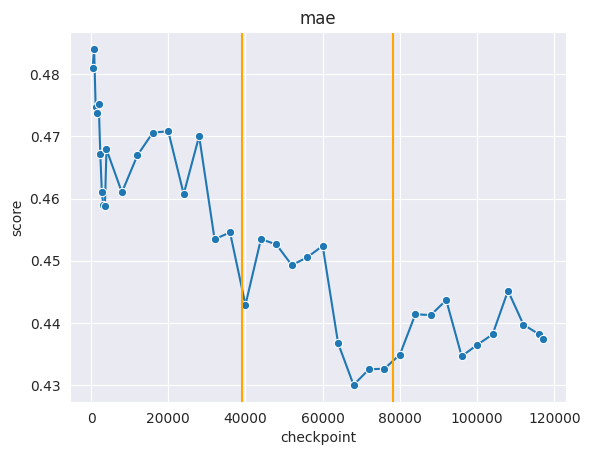

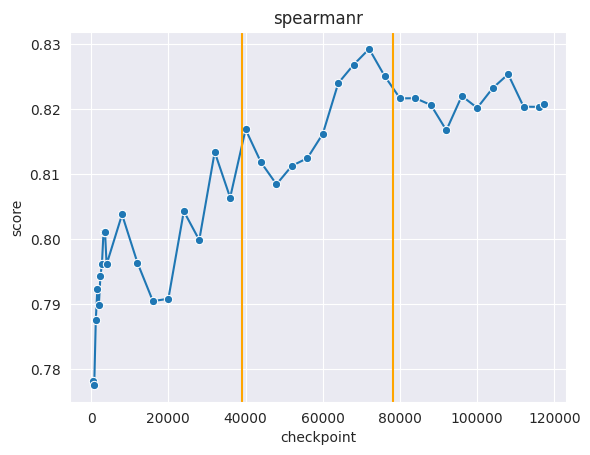

In [50]:
for metric in res_df['metric'].unique():
    metric_df = res_df[res_df['metric'] == metric]
    plt.figure()
    sns.lineplot(data=metric_df, x='checkpoint', y='score', marker='o')
    plt.axvline(39063, color='orange')
    plt.axvline(39063*2, color='orange')
    plt.title(f'{metric}')   
    plt.show() 

In [53]:
downstream_task = 'sentiment'
models_dir = f'../../models/downstream_tasks/{downstream_task}'
model_name = os.listdir(models_dir)[0]
res_df = get_model_results(models_dir, model_name)

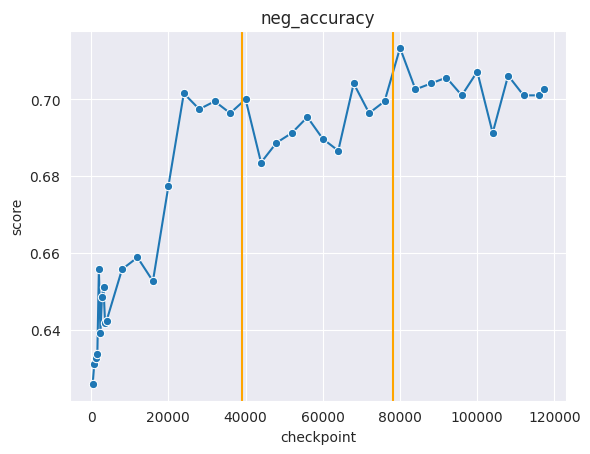

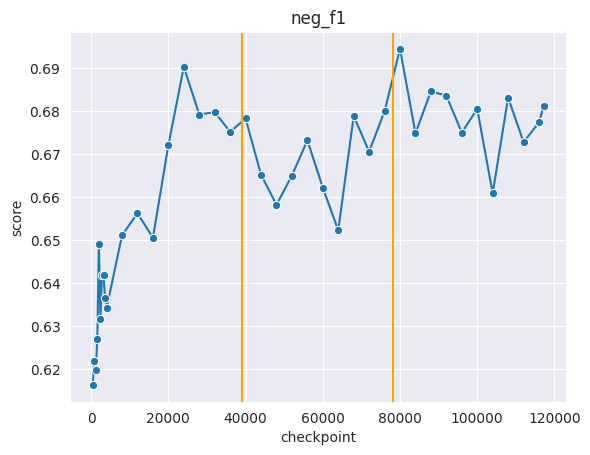

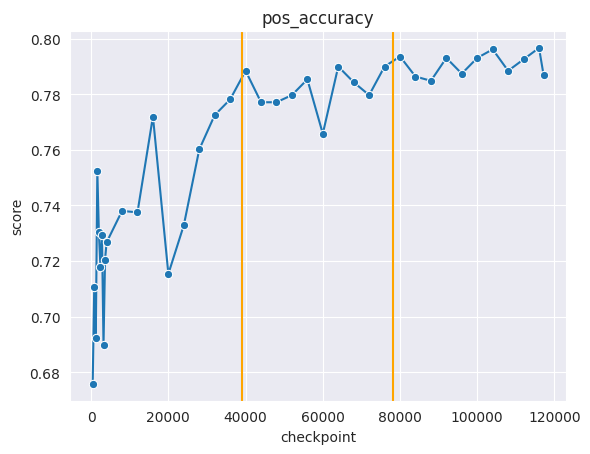

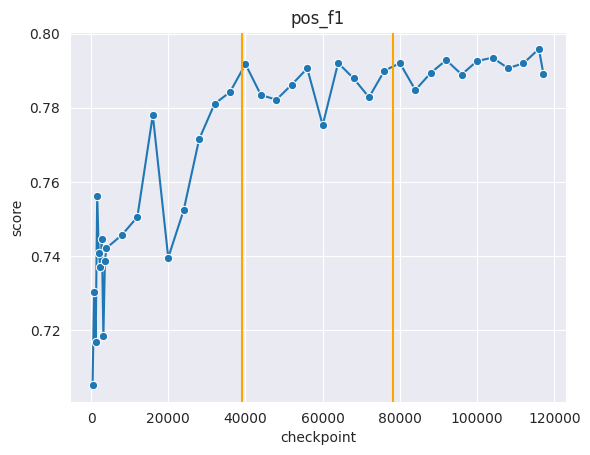

In [54]:
for metric in res_df['metric'].unique():
    metric_df = res_df[res_df['metric'] == metric]
    plt.figure()
    sns.lineplot(data=metric_df, x='checkpoint', y='score', marker='o')
    plt.axvline(39063, color='orange')
    plt.axvline(39063*2, color='orange')
    plt.title(f'{metric}')   
    plt.show() 

In [55]:
downstream_task = 'complexity'
models_dir = f'../../models/downstream_tasks/{downstream_task}'
model_name = os.listdir(models_dir)[0]
res_df = get_model_results(models_dir, model_name)

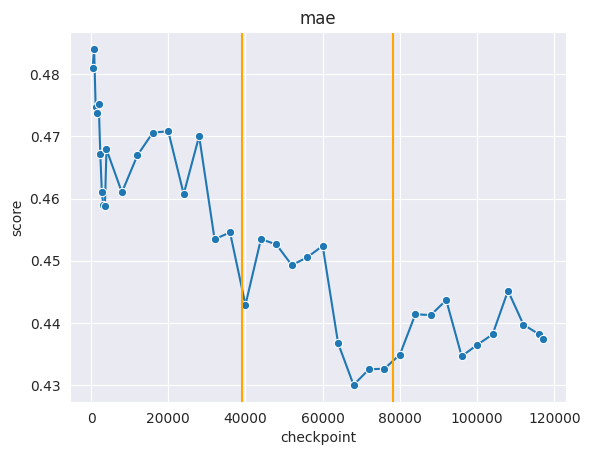

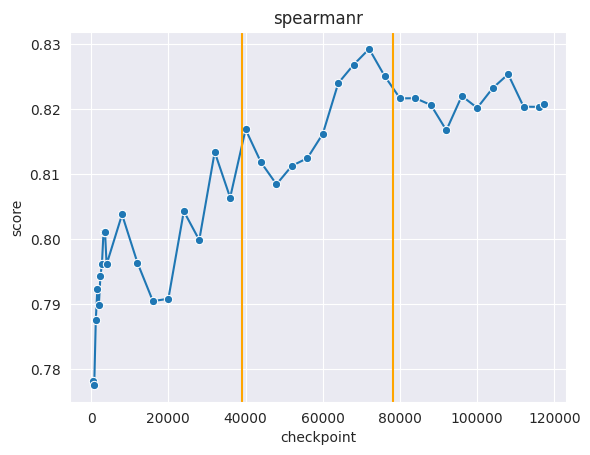

In [56]:
for metric in res_df['metric'].unique():
    metric_df = res_df[res_df['metric'] == metric]
    plt.figure()
    sns.lineplot(data=metric_df, x='checkpoint', y='score', marker='o')
    plt.axvline(39063, color='orange')
    plt.axvline(39063*2, color='orange')
    plt.title(f'{metric}')   
    plt.show() 